In [1]:
import os
import sys

import torch
from torch.distributions import constraints

import pyro
import pyro.poutine as poutine
import pyro.distributions as dist
from pyro.distributions import Bernoulli, Categorical, MultivariateNormal, Normal
from pyro.distributions.testing.fakes import NonreparameterizedBeta
from pyro.distributions.util import broadcast_shape
from pyro.infer import SVI, Trace_ELBO, TraceGraph_ELBO, config_enumerate
from pyro.optim import Adam

pyro.enable_validation(True)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.2)

from IPython.display import clear_output
from matplotlib.gridspec import GridSpec

## 1. Формы тензоров в PyTorch

PyTorch `Tensor`'s имеют один атрибут `.shape`, но семплы из `Distributions` имеют два атрибута формы с особым значением: `.batch_shape` и `.event_shape`. Эти две формы комбинируются для определения общей формы семпла.
* Индексы по размерностям из `.batch_shape` итерируются по условно независимым случайным величинам.
* тогда как индексы над `.event_shape` обозначают зависимые случайные величины (т.е. один семпл из распределения).

Например, если мы захотим сгенерировать выборку размера 10 их трехмерного нормального распределения, то для таких данных `batch_shape=(10,)` и `event_shape=(3,)`.

Метод `.log_prob()` вычисляет только одно число для каждого семпла формы `.event_shape`. Таким образом, форма возвращаемого значения в `.log_prob()` это `.batch_shape`.

Функция `Distribution.sample()` также принимает параметр `sample_shape`, индексирующий независимые одинаково распределенные случайные величины (iid). Таким образом, справедлива схема

              |      iid     | independent | dependent
        ------+--------------+-------------+------------
        shape = sample_shape + batch_shape + event_shape
        
Некоторые примеры

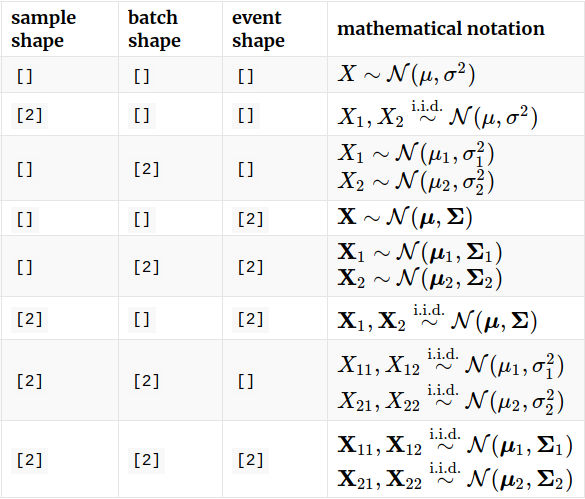

### 1.1 Примеры

**1.** Распределение $Bern(1/2)$

In [2]:
d = Bernoulli(0.5)
d.batch_shape, d.event_shape

(torch.Size([]), torch.Size([]))

Один семпл

In [3]:
x = d.sample()
x.shape, d.log_prob(x).shape

(torch.Size([]), torch.Size([]))

Выборка размера 10

In [4]:
x = d.sample(sample_shape=torch.Size([10]))
x.shape, d.log_prob(x).shape

(torch.Size([10]), torch.Size([10]))

**2.** Независимые распределения $Bern(1/2)$ в виде матрицы 3x4

In [5]:
d = Bernoulli(0.5 * torch.ones(3, 4))
d.batch_shape, d.event_shape

(torch.Size([3, 4]), torch.Size([]))

Один семпл

In [6]:
x = d.sample()
x.shape, d.log_prob(x).shape

(torch.Size([3, 4]), torch.Size([3, 4]))

Для создания батч-распределения можно также использовать метод `.expand()`. Этот метод работает только в том случае, если параметры идентичны по крайним левым измерениям.

**3.** Независимые распределения Бернулли в виде матрицы 3x4, причем вероятности успеха меняются по строке

In [7]:
d = Bernoulli(torch.tensor([0.1, 0.2, 0.3, 0.4])).expand([3, 4])
d.batch_shape, d.event_shape

(torch.Size([3, 4]), torch.Size([]))

Один семпл

In [8]:
x = d.sample()
x.shape, d.log_prob(x).shape

(torch.Size([3, 4]), torch.Size([3, 4]))

**4.** Трехмерное нормальное распределение

In [9]:
d = MultivariateNormal(torch.zeros(3), torch.eye(3, 3)).expand([5, 4])
d.batch_shape, d.event_shape

(torch.Size([5, 4]), torch.Size([3]))

Один семпл

In [10]:
x = d.sample()
x.shape, d.log_prob(x).shape

(torch.Size([5, 4, 3]), torch.Size([5, 4]))

### 1.2 Изменение формы распределения

В Pyro можно рассматривать одномерное распределение как многомерное, вызывая метод `.to_event(n)`, где $n$ — число *правых* batch-размерностей, которые должны быть объявлены *зависимыми*.

In [11]:
d = Bernoulli(0.5 * torch.ones(3, 4)).to_event(1)
d.batch_shape, d.event_shape

(torch.Size([3]), torch.Size([4]))

Один семпл

In [12]:
x = d.sample()
x.shape, d.log_prob(x).shape

(torch.Size([3, 4]), torch.Size([3]))

Часто в Pyro некоторые размерности объявляются зависимыми, даже если они на самом деле независимы, например

In [13]:
x = pyro.sample("x", Normal(0, 1).expand([10]).to_event(1))

Это позволяет легко поменять распредедение на `MultivariateNormal` позже.

## 2. Указание условной независимости

Pyro предоставляет два способа для обозначения условной независимости: `plate` и `markov`.

### 2.1 Последовательный `plate`

Вернемся к примеру, который мы использовали в предыдущем ноутбуке. Для удобства повторим основную логику `model` здесь:

$\theta \sim Beta(10, 10)$ — априорная информация.

$X\ |\ \theta \sim Bern(\theta)$ — испытания.

*Для сокращения объема кода "зашьем" априорные параметры внутрь распределения.*

In [ ]:
def model(data):
    # априорное распределение
    theta = pyro.sample("theta", dist.Beta(torch.tensor(10.0), torch.tensor(10.0)))

    # цикл наблюдаемых данных
    for i in range(len(data)):
        # наблюдаем объект i используя распр. Бернулли
        pyro.sample(f"obs_{i}", dist.Bernoulli(theta), obs=data[i])


pyro.render_model(model, model_args=(torch.zeros(5),))

Для этой модели наблюдения условно независимы, при условии скрытой случайной величины `theta`. Чтобы явно указать об этом в Pyro, нужно заменить `range` конструкцией `plate`:

In [ ]:
def model(data):
    # априорное распределение
    theta = pyro.sample("theta", dist.Beta(torch.tensor(10.0), torch.tensor(10.0)))

    # цикл наблюдаемых данных
    for i in pyro.plate("data_loop", len(data)):
        # наблюдаем объект i используя распр. Бернулли
        pyro.sample(f"obs_{i}", dist.Bernoulli(theta), obs=data[i])


pyro.render_model(model, model_args=(torch.zeros(5),))

Конструкция `pyro.plate` очень похожа на `range` с одним главным отличием: каждый вызов `plate` требует от пользователя предоставить **уникальное имя**. Второй аргумент — целое число, как и для `range`.

Теперь Pyro может использовать условную независимость наблюдений, учитывая скрытые случайные величины. При каждом выполнении тела `for`-цикла вводится новый условный контекст независимости, который завершается в конце тела `for`-цикла.

Подробнее:
* поскольку каждый вызов `pyro.sample` с переданными наблюдениями происходит в рамках различных итераций выполнения цикла `for`, Pyro отмечает каждое наблюдение как независимое от остальных;
* эта независимость является **условной независимостью** при условии `theta`, потому что `theta` определена вне контекста `data_loop`.

Прежде чем двигаться дальше, давайте упомянем некоторые конструкции, которых следует **избегать** при использовании последовательно `plate`. Рассмотрим следующий вариант приведенного выше фрагмента кода:

Это не приведет к желаемому поведению, так как `list()` соберет все объекты полностью из контекста `data_loop` **до первого вызова** `pyro.sample`. 

Кроме того, стоит отметить, что `pyro.plate` не подходит для временных моделей, где каждая итерация цикла зависит от предыдущей итерации; в этом случае вместо этого следует использовать `range` или `pyro.markov`.

### 2.2 Векторизованный `plate`

Векторизованный `plate` — тот же самый последовательный `plate`, за исключением того, что он является векторизованной операцией, подобно `torch.arange` по отношению к `range`. Таким образом, он потенциально обеспечивает большее ускорение по сравнению с явным `for`-циклом, который появляется при последовательном `plate` выполнении. 

Модифицируем наш пример

In [ ]:
def model(data):
    # априорное распределение
    theta = pyro.sample("theta", dist.Beta(torch.tensor(10.0), torch.tensor(10.0)))

    # контекст условной независимости
    with pyro.plate("observe_data"):
        # наблюдаем всю выборку используя распр. Бернулли
        pyro.sample("obs", dist.Bernoulli(theta), obs=data)


pyro.render_model(model, model_args=(torch.zeros(5),))

Сравним последовательным `plate`: 
- оба паттерна требуют указывать уникальное имя. 
- этот фрагмент кода вводит только одну наблюдаемую случайную величину (`obs`), так как весь тензор рассматривается сразу. 
- поскольку в этом случае нет необходимости в итераторе, нет необходимости указывать длину тензора, используемого в `plate`-контексте


**Упражнение.** Модифицируйте ваш код, используя векторизированный `pyro.plate`.

## 3. Использование батчей (субсэмплинг)

Отмечать условные независимости в Pyro полезно само по себе, но также это необходимо при использовании стохастичности по батчам. В зависимости от структуры модели и guide Pyro поддерживает несколько способов выполнения субсэмплинга. 

### 3.1 Автоматический субсэмплинг с помощью `plate`

Сначала рассмотрим случай последовательного `plate`. Все, что нужно сделать, просто указать аргумент `subsample_size`, задающий размер батча.

In [ ]:
def model(data):
    # априорное распределение
    theta = pyro.sample("theta", dist.Beta(torch.tensor(10.0), torch.tensor(10.0)))

    # цикл наблюдаемых данных
    for i in pyro.plate("data_loop", len(data), subsample_size=5):
        # наблюдаем объект i используя распр. Бернулли
        pyro.sample(f"obs_{i}", dist.Bernoulli(theta), obs=data[i])


pyro.render_model(model, model_args=(torch.zeros(1000),))

Теперь когда мы запускаем `model()`, оцениваем логарифмическую плотность только для 5 случайно выбранных точек данных `data`. Кроме того, логарифмическая плотность будет автоматически масштабироваться соответствующим коэффициентом, например, $10/5=2$ для выборки размера 10. 

Для векторизованного `plate` аналогично:

In [ ]:
def model(data):
    # априорное распределение
    theta = pyro.sample("theta", dist.Beta(torch.tensor(10.0), torch.tensor(10.0)))

    # контекст условной независимости
    with pyro.plate("observe_data", size=len(data), subsample_size=5) as ind:
        # наблюдаем батч используя распр. Бернулли
        pyro.sample("obs", dist.Bernoulli(theta), obs=data.index_select(0, ind))


pyro.render_model(model, model_args=(torch.zeros(1000),))

Важно отметить, что `plate` теперь возвращает тензор индексов `ind`, который в данном случае будет иметь длину 5. Так же как и для последовательного `plate`, **пользователь ответственен за выбор правильного батча**, используя индексы, предоставляемые с помощью `plate`. Почему это важно? Контест `plate` может использоваться как в `model`, так и в `guide`, и более того &mdash; при оценке ELBO. Pyro гарантирует, что на всех этапах в рамках одной итерации `plate` выдает одинаковый набор индексов, соответствующий батчу текущей итерации.

Обратите внимание, что в дополнение к аргументу `subsample_size` мы также передаем аргумент `size` для того, чтобы `plate` знал полный размер тензора `data` для вычисления правильного коэффициент масштабирования.

*Замечания.*
1. Каждый раз `plate` отбирает новые индексы подвыборок. Этот субсемплинг не имеет состояния, что может привести к некоторым проблемам. Например, для достаточно большого набора данных даже после большого числа итераций существует некоторая вероятность того, что некоторая часть данных никогда не будет выбрана. Чтобы избежать этого, пользователь может управлять субсэмплингом, используя аргумент `subsample` в `plate`. 
2. Если данные `data` находятся на GPU, нужно соответственно определить аргумент `device` в `plate`.

**Упражнение.** Модифицируйте ваш код, применив субсэмплинг.

### 3.2 Субсэмплинг при наличии только локальных случайных величин
Рассмотрим модель с совместной плотностью
$$p(x, y) = \prod_{i=1}^n p(x_i|y_i)p(y_i).$$
Для модели с такой структурой зависимостей масштабирующий коэффициент, введенный вследствии субсэмплинга, масштабирует все члены в ELBO на одну и ту же величину. 

Пример на следующем занятии.

### 3.3 Субсэмплинг при наличии как глобальных, так и локальных случайных величин
Ранее в наших примерах контекст `plate` появлялся в модели, но не в guide, так как единственное, что было с ним связано — наблюдения. Рассмотрим более сложный пример, где субсэмплинг появляется как в модели, так и в guide. 

Рассмотрим модель, заданную следующим совместным распределением:
$$p(x, y, \beta) = p(\beta)\prod_{i=1}^n p(x_i|y_i)p(y_i|\beta)$$

В данном случае мы имеем
* $n$ наблюдений $\{X_i\}$ 
* $n$ локальных латентных случайных величин $\{Y_i\}$
* глобальную латентную случайную величину $\beta$. 

Наш guide будет факторизован следующим образом
$$q(y, \beta) = q(\beta) \prod_{i=1}^n q_{\varphi_i}(y_i|\beta)$$

Здесь мы явно ввели $n$ локальных вариационных параметров $\varphi_i$, в то время как другие вариационные параметры остаются неявными (т.е. мы их просто не указали). И модель, и guide имеют условную независимость:
* В модели наблюдения $\{X_i\}$ условно независимы при условии $\{Y_i\}$. Кроме того, при условии $\beta$ скрытые величины $\{Y_i\}$ независимы. 
* В guide скрытые величины $\{Y_i\}$ условно независимы при условии $\beta$. 

Чтобы задать эти условные независимости в Pyro и сделать подвыборку, нам нужно использовать `plate` в сразу модели и в guide. 

Во-первых, модель:

In [ ]:
def model(data):
    beta = pyro.sample("beta", ...)

    for i in pyro.plate("locals", len(data)):
        y_i = pyro.sample(f"y_{i}", ...)

        theta_i = compute_something(y_i)
        pyro.sample(f"obs_{i}", dist.MyDist(theta_i), obs=data[i])

Обратите внимание, что в отличие от примера с подбрасыванием монет, в данном случае есть `pyro.sample`-операторы как внутри, так и вне `plate`-цикла.

Далее guide:

In [ ]:
def guide(data):
    beta = pyro.sample("beta", ...)

    for i in pyro.plate("locals", len(data), subsample_size=5):
        pyro.sample(f"y_{i}", ..., lambda_i)

Обратите внимание, что индексы батча генерируются только один раз в guide. Бэкэнд Pyro гарантирует, что один и тот же набор индексов будет использоваться в рамках одной итерации. По этой причине `subsample_size` **необходимо только указать в guide**.

## 4. Оценки ELBO или проклятие дисперсии


Ранее мы определили pyro-модель с наблюдениями $X$ и латентными величинами $Y$ в виде $p_{\theta}(x, y) = p_{\theta}(x|y) p_{\theta}(y)$. Мы также определили guide (т.е. вариационное распределение) в виде $q_{\varphi}(y)$. Здесь ${\theta}$ и $\varphi$ это неслучайные параметры модели и guide соответственно. 

Мы бы хотели максимизировать логарифм обоснованности $\log p_{\theta}(x)$ максимизацией ELBO, заданной как

$${\rm ELBO} = \mathsf{E}_{q_{\varphi}} \left ( 
\log p_{\theta}(X, Y) - \log q_{\varphi}(Y)
\right)$$

Для этого сделаем SGD по ELBO в пространстве параметров $(\theta, \varphi)$. Таким образом, нам нужно вычислять несмещенные оценки

$$\nabla_{\theta,\varphi} {\rm ELBO} = \nabla_{\theta,\varphi}\mathsf{E}_{q_{\varphi}} \left ( 
\log p_{\theta}(X, Y) - \log q_{\varphi}(Y)
\right)$$

Как это делается для стохастических функций `model()` и `guide()` общего вида? Чтобы упростить нотацию, рассмотрим градиенты математических ожиданий произвольной функции потерь  $f(y)$, отбросив также всякое различие между $\theta$ и $\varphi$. Итак, мы хотим вычислить

$$\nabla_{\varphi}\mathsf{E}_{q_{\varphi}}
f_{\varphi}(Y) $$

Начнем с самого простого случая


### 4.1 Простой случай: репараметризация

Предположим, существует репараметризация: 
$$Y = g(Z, \varphi),$$
где $Z$ имеет плотность $\rho(z)$, которая не зависит от $\varphi$. Например, если $\varphi=(\varphi_1, \varphi_2)$ — параметры сдвига и масштаба соответственно, то $g(Z, \varphi) = \varphi_1 + \varphi_2 Z$.

Получаем
$$\mathsf{E}_{q_{\varphi}} f_{\varphi}(Y) 
=\mathsf{E}_{\rho} f_{\varphi}(g(Z, \varphi)) $$

Тем самым мы свели выражение к математическому ожиданию по фиксированному распределению, не зависящему от $\varphi$. В таком случае мы можем пронести градиент через математическое ожидание, получив

$$\nabla_{\varphi} \mathsf{E}_{q_{\varphi}} f_{\varphi}(Y)=
\mathsf{E}_{\rho} \nabla_{\varphi} f_{\varphi}(g(Z, \varphi))$$

Предполагая, что $f$ и $g$ достаточно гладкие, можем получить несмещенные оценки градиента, взяв оценку этого математического ожидания по методу Монте-Карло.

### 4.2 Сложный случай

Что делать, если мы не сможем выполнить описанную выше репараметризацию? К сожалению, такая ситуация происходит довольно часто, например при рассмотрении дискретных распределений. В этом случае наша оценка принимает несколько более сложную форму.

Как мы выяснили ранее, градиент можно представить в следующем виде
$$\nabla_{\varphi}\mathsf{E}_{q_{\varphi}}
f_{\varphi}(Y) = 
\mathsf{E}_{q_{\varphi}} \bigg [\big(\nabla_{\varphi} \log q_{\varphi}(Y)\big) f_{\varphi}(Y) + \nabla_{\varphi} f_{\varphi}(Y)\bigg]$$
В таком виде его уже можно оценивать при помощи Монте-Карло.


К сожалению, в общем случае, когда $q$ включает в себя нерепараметризуемые случайные величины, **такая оценка часто имеет огромную дисперсию**. Во многих интересных примерах дисперсия настолько высока, что оценка фактически непригодна для использования. Соответственно, нам нужны стратегии для уменьшения дисперсии.

Приведем две стратегии. 
* Использование преимуществ конкретной структуры функции $f$. 
* Применение снижения дисперсии за счет использования информации из предыдущих оценок, что несколько аналогично использованию импульса при стохастическом градиентном спуске.

### 4.3 Уменьшение дисперсии с помощью структуры зависимостей

Оказывается, в выражении выше можно удалить некоторые слагаемые в $f_{\varphi}(Y)$ и все еще получить несмещенную оценку градиента, обладающую меньшей дисперсией. В частности мы можем **удалить любые слагаемые** в $f_{\varphi}(Y)$, которые находятся не ниже латентной величины $Y_i$ в графе зависимостей, соответствующему определенному guide. Часто такой подход называется **Рао-Блэквеллизацией**, и соответствует **поиску полной и достаточной статистики**.

В Pyro вся эта логика выполняется автоматически классом `SVI`. В частности при использовании лосса `TraceGraph_ELBO` Pyro будет отслеживать структуру зависимостей в при выполнении модели и guide и строить функцию, у которой будут удалены все ненужные слагаемые:

```python
svi = SVI(model, guide, optimizer, TraceGraph_ELBO())
```

Обратите внимание, что использование этой информации о зависимостях требует дополнительных вычислений, поэтому `TraceGraph_ELBO` следует использовать только в том случае, когда ваша модель имеет непараметрируемые случайные величины. В большинстве приложений достаточно `Trace_ELBO`.

**Пример**

Предположим, что у нас есть модель гауссовой смеси с $K$ компонентами. Для каждой точки данных: 
* генерируем номер компоненты $k \in [1,...,K]$; 
* наблюдаем семпл из $k$-й компоненты. 

Такую модель можно записать следующим образом:

```python
ks = pyro.sample(
    "k", 
    dist.Categorical(probs).to_event(1)
)
pyro.sample(
    "obs", 
    dist.Normal(locs[ks], scale).to_event(1),
    obs=data
)
```

В данном случае не отмечена какая-либо условная независимость в модели, поэтому при построении оценки градиента класс `SVI` в Pyro не может воспользоваться преимуществами Rao-Blackwellization, в результате чего она оценка будет иметь высокую дисперсии. 

Для решения этой проблемы пользователю необходимо явно отметить условную независимость, что делается следующим образом:


```python
# отмечаем условную независимость предполагая
# что она находится вдоль самой последней тензорной размерности
with pyro.plate("foo", data.size(-1)):
    ks = pyro.sample(
        "k", 
        dist.Categorical(probs)
    )
    pyro.sample(
        "obs", 
        dist.Normal(locs[ks], scale),
        obs=data
    )
```      

### 4.4 Уменьшение дисперсии с помощью baselines (аналог CUPED 🙃)

Вторая стратегия уменьшения дисперсии в нашем градиентном оценщике ELBO называется baselines. Фактически использует тот же математический трюк, который лежит в основе стратегии уменьшения дисперсии, рассмотренной выше, за исключением того, что теперь вместо удаления слагаемых мы будем **добавлять слагаемые**. Добавим специально подобранное слагаемое с нулевым математическим ожиданием, которое уменьшит дисперсии. Таким образом, это стратегия контроля дисперсии.

Идея состоит в том, чтобы воспользоваться следующим фактом. Для любой константы $b$, имеет место следующее тождество
$$\mathsf{E}_{q_{\varphi}} \nabla_{\varphi}
(\log q_{\varphi}(Y) \cdot b) =0$$

Это следует из того, что $q(\cdot)$ является нормированной плотностью:

$$\mathsf{E}_{q_{\varphi}} \nabla_{\varphi}
\log q_{\varphi}(Y) =
 \int q_{\varphi}(y) \nabla_{\varphi}
\log q_{\varphi}(y)\; \!dy =
 \int \nabla_{\varphi}
 q_{\varphi}(y)\; \!dy 
=
 \nabla_{\varphi} \int
 q_{\varphi}(y)\; \!dy 
=\nabla_{\varphi} 1 = 0$$

В результате ELBO можем немного поправить как
$$\log q_{\varphi}(y) \left(f_{\varphi}(y)-b\right) $$

Это не влияет на среднее значение нашей оценки градиента, но влияет на дисперсию. Если мы выберем $b$ разумно, можно надеяться на то, что это уменьшить дисперсию. На самом деле, $b$ не обязательно быть константой: она может зависеть от любого набора случайных величин, находящихся ранее $Y$ в графе зависимостей.

#### Baselines in Pyro

Существует несколько способов, которыми в Pyro можн использовать baselines в контексте стохастического вариационного вывода. Поскольку baselines могут быть присоединены к любой непараметризуемой случайной переменной, текущий интерфейс baselines находится на уровне `pyro.sample`. В частности, интерфейс этой функции содержит аргумент `baseline`, который является словарем, определяющим параметры baselines. Обратите внимание, что имеет смысл указывать baselines только для семплов в guide (и не в модели).

##### Decaying Average Baseline

Простейшая baselines является скользящим средним последних значений $f_{\varphi}(y)$. В Pyro этот вид Baseline может быть вызван следующим образом

```python
z = pyro.sample(
    "z", 
    dist.Bernoulli(...), 
    infer=dict(baseline={'use_decaying_avg_baseline': True,
                         'baseline_beta': 0.95})
)
```

Необязательный аргумент `baseline_beta` задает скорость затухания скользящего среднего, значение по умолчанию равно `0.90`.

#### Neural Baselines

Мощный подход к построению Baselines заключается в использовании нейронной сети, которая может быть адаптирована в ходе обучения. 

Сначала нужно решить, какие данные на вход будет принимать такая Baselines. Например, текущая рассматриваемая наблюдаемая случайная величина или ранее выбранная случайная величина. Затем необходимо построить класс нейронной сети. Это может выглядеть примерно так

```python
class BaselineNN(nn.Module):
    def __init__(self, dim_input, dim_hidden):
        super().__init__()
        self.linear = nn.Linear(dim_input, dim_hidden)
        # ... finish initialization ...

    def forward(self, x):
        hidden = self.linear(x)
        # ... больше вычислений ...
        return baseline
```

Затем, предполагая, что `baseline_module` -- объект класса `BaselineNN`, в guide пишем

```python
def guide(x):  # здесь x-это текущий мини-батч данных
    
    pyro.module("my_baseline", baseline_module)
    # ... other computations ...
    
    y = pyro.sample(
        "y", 
        dist.Bernoulli(...), 
        infer=dict(baseline={'nn_baseline': baseline_module,
                             'nn_baseline_input': x})
    )
```

Здесь аргумент `nn_baseline` говорит Pyro, что для построения baseline использовать объект класса `nn.Module`. На бэкэнде аргумент `nn_baseline_input` передается forward-метод модуля вычисления baseline. Обратите внимание, что baseline должен быть зарегистрирован в Pyro с помощью вызова `pyro.module`, чтобы Pyro знал о обучаемых параметрах внутри модуля.

Нет никакой теории, которая утверждает об оптимальности такого подхода, но на практике он может работать довольно хорошо. Точно так же, как и для Decaying Average Baseline, идея заключается в том, что baseline поможет уменьшить дисперсию. Под капотом  `SVI` делает один шаг baseline-лосса в сочетании с шагом по ELBO. 

На практике может быть важно использовать другой набор гиперпараметров (например, более высокую скорость обучения) для параметров Baseline. В Pyro это можно сделать следующим образом:

```python
def per_param_args(module_name, param_name):
    if 'baseline' in param_name or 'baseline' in module_name:
        return {"lr": 0.010}
    else:
        return {"lr": 0.001}
    
optimizer = optim.Adam(per_param_args)
```

Обратите внимание, что для корректности необходио параметры Baseline оптимизировать только за счет baseline-лосса. 

Наконец, существует альтернативный способ для пользователя указать нейронную Baseline. Просто используйте аргумент `baseline_value`:

```python
b = # do baseline computation
z = pyro.sample(
    "z", 
    dist.Bernoulli(...), 
    infer=dict(baseline={'baseline_value': b})
)
```



### 4.5 Полный пример с baselines

Ранее мы рассмотрели модель для подбрасывания монет. Поскольку бета-распределение нерепараметризуемо, соответствующие градиенты ELBO могут быть довольно шумными. В этом контексте проблема решается путем использования **приблизительных репараметризованных градиентов**. 
Посмотрим, как простой decaying average baseline может уменьшить дисперсию.

Вместо прямого сравнения дисперсий градиентов посмотрим, сколько шагов требуется для сходимости `SVI`. Напомним, что для этой конкретной модели (из-за сопряженности) мы можем вычислить точное апостериорное распределение. Поэтому, чтобы оценить пользу baseline в этом контексте, поставим следующий простой эксперимент:
* Проинициализируем guide при заданном наборе вариационных параметров. 
* Делаем SVI до тех пор, пока вариационные параметры не окажутся в заданной окрестности апостериорного распределения.
* Сделаем это как с decaying average baseline, так и без нее. 
* Затем мы сравним количество шагов, необходимых в этих двух случаях.


In [ ]:
from pyro.distributions.testing.fakes import NonreparameterizedBeta

class BernoulliBetaExample:
    def __init__(self, data, max_steps):
        self.max_steps = max_steps  # максимальное количество шагов вывода

        self.data = torch.tensor(data)
        self.data_len = self.data.size(0)

        self.alpha_prior = 10.0
        self.beta_prior = 10.0

        # Инициализация вариационных параметров
        self.alpha_q_0 = torch.tensor(15.0)
        self.beta_q_0 = torch.tensor(15.0)

    def model(self, reparameterized, use_decaying_avg_baseline):
        # априорное распределение
        theta = pyro.sample("theta", dist.Beta(self.alpha_prior, self.beta_prior))

        # контекст условной независимости
        with pyro.plate("observe_data"):
            # наблюдаем всю выборку используя распр. Бернулли
            pyro.sample("obs", dist.Bernoulli(theta), obs=self.data)

    def guide(self, reparameterized, use_decaying_avg_baseline):
        alpha = pyro.param("alpha_q", self.alpha_q_0, constraint=constraints.positive)
        beta = pyro.param("beta_q", self.beta_q_0, constraint=constraints.positive)

        if reparameterized:
            # Используем репараметризованное приближение бета-распределения
            pyro.sample(
                "theta",
                dist.Beta(alpha, beta),
            )

        else:
            baseline_dict = {
                "use_decaying_avg_baseline": use_decaying_avg_baseline,
                "baseline_beta": 0.9,
            }

            # Используем нерепараметризованное бета-распределение
            pyro.sample(
                "theta", NonreparameterizedBeta(alpha, beta), infer=dict(baseline=baseline_dict)
            )

    def callback(self, trace, it):
        # Отложенная очистка экрана
        clear_output(wait=True)

        # Объявление фигуры и сетки
        fig = plt.figure(figsize=(10, 10), constrained_layout=True)
        plt.suptitle(f"Итерация {it}")
        gs = GridSpec(3, 2, figure=fig)

        # График вероятностей кластеров
        for i, label in enumerate(trace.keys()):
            if i == 0:
                ax = fig.add_subplot(gs[0, :])
            else:
                ax = fig.add_subplot(gs[(i + 1) // 2, (i + 1) % 2])
            ax.plot(trace[label], lw=2, color="#00CC66")
            ax.set_xlabel("Номер итерации")
            ax.set_title(label)
        sns.set_style("darkgrid")

        plt.tight_layout()
        plt.show()

    def visualize_or_not(self, it, n_iter):
        return (
            (it < 10)
            or ((it % 10 == 0) and (it < 100))
            or ((it % 100 == 0) and (it < 1000))
            or (it % 1000 == 0)
        )

    def fit(self, reparameterized, use_decaying_avg_baseline=True):
        # Очищаем хранилище параметров
        pyro.clear_param_store()

        # Задаем оптимизатор и метод вывода
        optimizer = Adam({"lr": 0.0005, "betas": (0.93, 0.999)})
        svi = SVI(self.model, self.guide, optimizer, loss=TraceGraph_ELBO())

        # Выполняем шаги
        trace = {"ELBO": [], "alpha": [], "beta": []}
        for k in range(self.max_steps):
            loss = svi.step(reparameterized, use_decaying_avg_baseline)

            trace["ELBO"].append(-loss)
            trace["alpha"].append(pyro.param("alpha_q").item())
            trace["beta"].append(pyro.param("beta_q").item())

            if self.visualize_or_not(k, self.max_steps):
                self.callback(trace, k)

Данные

In [ ]:
n = 10
data = torch.distributions.Bernoulli(0.6).sample(torch.Size([n]))
data

Параметры апостериорного распределения

In [ ]:
10 + data.sum(), 10 + n - data.sum()

Запуск с использованием baseline без репараметризации

In [ ]:
bbe = BernoulliBetaExample(data=data, max_steps=10001)
bbe.fit(reparameterized=False, use_decaying_avg_baseline=True)

Запуск без использования baseline без репараметризации

In [ ]:
bbe = BernoulliBetaExample(data=data, max_steps=10001)
bbe.fit(reparameterized=False, use_decaying_avg_baseline=False)

Запуск без использования baseline с приближенной репараметризацией

In [ ]:
bbe = BernoulliBetaExample(data=data, max_steps=10001)
bbe.fit(reparameterized=True)

**Упражнение.** Поставьте аналогичные эксперименты в примере с гамма-нормальным распределением, используя

`pyro.distributions.testing.fakes.NonreparameterizedGamma`

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока